# Simple Parallel Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

model= ChatGroq(model= "llama-3.1-8b-instant")

In [3]:
#State
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int
    
    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [18]:
# actions
def calculate_sr(state:BatsmanState):
    
    sr = (state['runs']/state['balls'])*100

    return {'sr':sr}

def calculate_bpb(state:BatsmanState):
    
    bpb = state['balls']/(state['fours']+state['sixes'])
    
    return {'bpb':bpb}

def boundary_percent(state:BatsmanState):
    boundary_percent = ((state['fours']*4)+(state['sixes']*6))/state['runs']
    
    return {'boundary_percent':boundary_percent}

def summary(state:BatsmanState):
    
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundary - {state['bpb']} \n 
    Boundary percent - {state['boundary_percent']}
    
    """
    
    return {'summary':summary}

In [19]:
# Nodes
graph= StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('boundary_percent', boundary_percent)
graph.add_node('summary', summary)


In [20]:
# Edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('boundary_percent','summary')

graph.add_edge('summary', END)

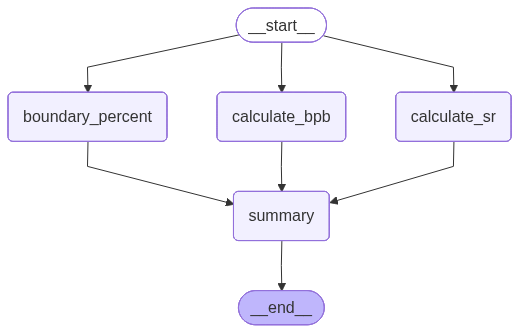

In [21]:
# compile

graph.compile()

In [22]:
workflow= graph.compile()

In [23]:
initial_state = {    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4}


final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 0.48, 'summary': '\n    Strike Rate - 200.0 \n\n    Balls per boundary - 5.0 \n \n    Boundary percent - 0.48\n\n    '}
